## Import libraries

In [1]:
import tomopy
from helperFunctions import MoviePlotter, subpixel_shift
from tomoDataClass import tomoData, simulate_projections
from alignment_methods import sinogram_consistency_score, reconstruction_sharpness_score


PyTorch imported successfully.
SVMBIR imported successfully.


## Create Simulated Data

In [2]:
#Set constants
numAngles = 100 #Number of projection angles
imageSize = 128 #Pixel size of one side of cubic array containing Shepp3D phantom

#Create a simulated object
obj = tomopy.shepp3d(size=imageSize)
print(obj.shape)
print("Simulated Object")
MoviePlotter(obj) #Plots vertical slices through the phantom

(128, 128, 128)
Simulated Object


Output()

In [3]:
import numpy as np
# Set projection angles
angles = tomopy.angles(nang=numAngles, ang1=-71.99, ang2=58.80)
# angles = tomopy.angles(nang=numAngles, ang1=-90, ang2=90)

# create projection images/sinogram
projections = simulate_projections(obj, angles, pad=False, use_astra=False)
# pad projections to be 30 pixels larger on each side
projections = np.pad(projections, ((0, 0), (30, 30), (30, 30)), mode='constant', constant_values=0)

print("Projections through object")
MoviePlotter(projections)

Projections through object


Output()

In [4]:
# Centre angles around 0 so the tilt series is symmetric
angles = angles - np.mean(angles)

In [5]:
tomo = tomoData(projections, angles)
tomo.makeNotebookProjMovie()

tomo.reconstruct(algorithm='gridrec')
print('Ideal reconstruction (no jitter, no noise)')
tomo.makeNotebookReconMovie()

Output()



Using CPU-based reconstruction. Algorithm:  gridrec
Reconstruction completed.
Ideal reconstruction (no jitter, no noise)


Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Error.  nthreads must be a positive integer

Output()

## Align Data

In [ ]:
#Show bad reconstruction prior to alignment
tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize) #You can adjust these for tighter cropping
tomo.normalize(isPhaseData=True)

tomo.reconstruct(algorithm='art')
print("\nBad reconstruction prior to alignment")
badRecon = tomo.recon.copy()
MoviePlotter(badRecon)

In [ ]:
# Sinogram consistency score — before alignment
combined_rmse_before, x_rmse_before, y_rmse_before, _, _ = sinogram_consistency_score(tomo, plot=True)

# Baseline sharpness — before alignment
grad_before, lap_before, _, _ = reconstruction_sharpness_score(badRecon, plot=True, percentile_crop=5)
print(f"\nBaseline  →  Gradient: {grad_before:.6f}  |  Laplacian: {lap_before:.6f}")

In [ ]:
tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize)
tomo.normalize(isPhaseData=True)

#Best XC params from sweep:
# Coarse passes: stepRatio=0.9 (stable global convergence)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=15, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=4, use_grad=True)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=15, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=2, use_grad=True)
# Final pass: stepRatio=0.75-0.8 with more iterations (fine-scale sharpness)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=30, stepRatio=0.8, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=1, use_grad=True)


#Best VMF params from sweep:
# tomo.vertical_mass_fluctuation_align(tolerance=0, max_iterations=1, y_range=None, sigma=None, smooth_sigma=1.0, window='soft_roi', roi_sigma=0.3, use_gradient=True, plot=True)

tomo.PMA(max_iterations=5, tolerance=0, algorithm='art', levels=3, scale=2, iterations_per_level=[5,5,2], shift_method='optical_flow', of_sigma=3.0, plot=True)
tomo.make_updates_shift()

In [ ]:
tomo.makeNotebookProjMovie()

tomo.reconstruct(algorithm='art')
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

In [ ]:

# Sinogram consistency score — after alignment
combined_rmse_after, x_rmse_after, y_rmse_after, _, _ = sinogram_consistency_score(tomo, plot=True)

# Reconstruction sharpness score — after alignment
grad_after, lap_after, _, _ = reconstruction_sharpness_score(tomo.recon, plot=True, percentile_crop=5)

print("=" * 62)
print("  ALIGNMENT QUALITY SUMMARY")
print("=" * 62)
print(f"\n{'Sinogram Consistency  (lower RMSE = better)':}")
print(f"  {'Metric':<22} {'Before':>10} {'After':>10} {'Δ (improvement)':>16}")
print(f"  {'-'*60}")
print(f"  {'X RMSE (px)':<22} {x_rmse_before:>10.4f} {x_rmse_after:>10.4f} {x_rmse_before - x_rmse_after:>+16.4f}")
print(f"  {'Y RMSE (px)':<22} {y_rmse_before:>10.4f} {y_rmse_after:>10.4f} {y_rmse_before - y_rmse_after:>+16.4f}")
print(f"  {'Combined RMSE (px)':<22} {combined_rmse_before:>10.4f} {combined_rmse_after:>10.4f} {combined_rmse_before - combined_rmse_after:>+16.4f}")

print(f"\n{'Reconstruction Sharpness':}")
print(f"  {'Metric':<22} {'Before':>10} {'After':>10} {'Δ (improvement)':>16}")
print(f"  {'-'*60}")
print(f"  {'Gradient':<22} {grad_before:>10.6f} {grad_after:>10.6f} {grad_after - grad_before:>+16.6f}")
print(f"  {'Laplacian variance':<22} {lap_before:>10.6f} {lap_after:>10.6f} {lap_after - lap_before:>+16.6f}")
print("=" * 62)

## POCS Reconstruction with Compact-Support Constraint

POCS (Projections Onto Convex Sets) alternates between two constraints:

1. **Data fidelity** — SIRT iterations pull the estimate toward the measured sinogram.
2. **Compact support** — voxels outside the object boundary are zeroed; density is clipped to ≥ 0.

Alternating between these two convex sets is guaranteed to converge to a solution that satisfies both. For limited-angle data the missing wedge tends to smear mass outside the true object; the support constraint removes that smearing.

In [6]:
import astra
import matplotlib.pyplot as plt
from scipy.ndimage import binary_closing
from tqdm.notebook import tqdm as tqdm_nb

# ── Prepare projections ───────────────────────────────────────────────────
# Use the aligned, normalised projections produced by the pipeline above.
mw_projs  = tomo.finalProjections    # (n_angles, n_rows, n_cols)
mw_angles = tomo.ang                 # radians, centred around 0
N         = mw_projs.shape[2]        # reconstruction side length
n_rows    = mw_projs.shape[1]

# Shift projections so the rotation axis falls exactly at the detector centre.
# ASTRA assumes a centred geometry; this corrects sub-pixel offsets.
center   = tomopy.find_center_vo(mw_projs)
shift_px = int(round(N / 2.0 - center))
mw_projs_c = np.stack([subpixel_shift(proj, 0, shift_px) for proj in mw_projs]) if shift_px != 0 else mw_projs
print(f'Rotation centre: {center:.2f} px  (shifted by {shift_px:+d} px)')

# ── Build ASTRA forward/back-projector ───────────────────────────────────
# OpTomo exposes A (forward) and Aᵀ (back-project) as matrix operators
# so we can write the SIRT update in plain NumPy.
vol_geom  = astra.create_vol_geom(N, N)
proj_geom = astra.create_proj_geom('parallel', 1.0, N, mw_angles.astype(np.float64))
proj_id   = astra.create_projector('line', proj_geom, vol_geom)
W         = astra.OpTomo(proj_id)
print(f'ASTRA projector ready  (N={N}, {len(mw_angles)} angles)')

# ── Estimate the Lipschitz constant of AᵀA ───────────────────────────────
# Sets a stable SIRT step size: α = 0.25 / L
def power_iteration(W, N, n_iter=20, seed=0):
    v = np.random.default_rng(seed).random(N * N).astype(np.float32)
    for _ in range(n_iter):
        v = (W.T * (W * v)).astype(np.float32)
        nrm = np.linalg.norm(v)
        if nrm > 0:
            v /= nrm
    return float(np.linalg.norm(W.T * (W * v)) / (np.linalg.norm(v) + 1e-12))

print('Estimating SIRT step size...', end=' ', flush=True)
L = power_iteration(W, N)
print(f'done  (L = {L:.2f},  step α = {0.25/L:.2e})')

Rotation centre: 93.00 px  (shifted by +1 px)
ASTRA projector ready  (N=188, 100 angles)
Estimating SIRT step size... done  (L = 18030.36,  step α = 1.39e-05)


POCS: 12 outer × 20 SIRT steps = 240 total per row


POCS outer iterations:   0%|          | 0/12 [00:00<?, ?it/s]

  outer 1/12 — support: 35.2% of voxels


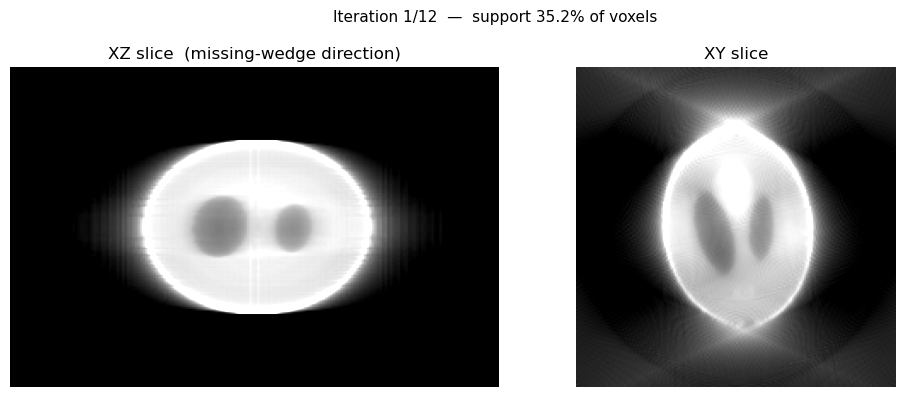

  outer 2/12 — support: 25.1% of voxels


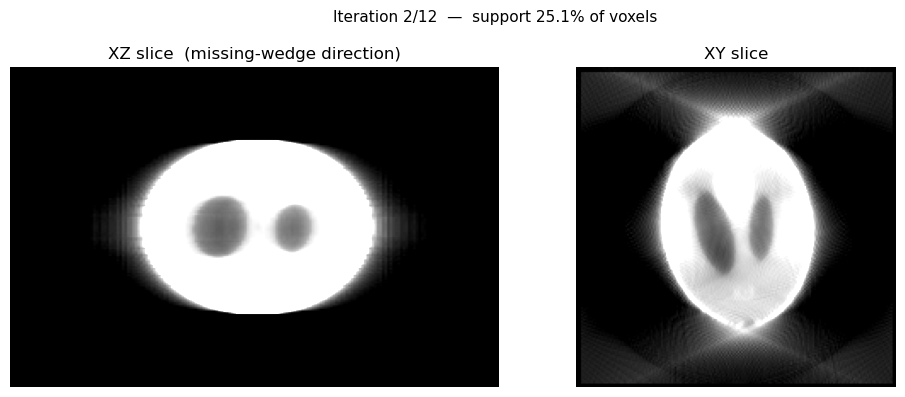

  outer 3/12 — support: 20.4% of voxels


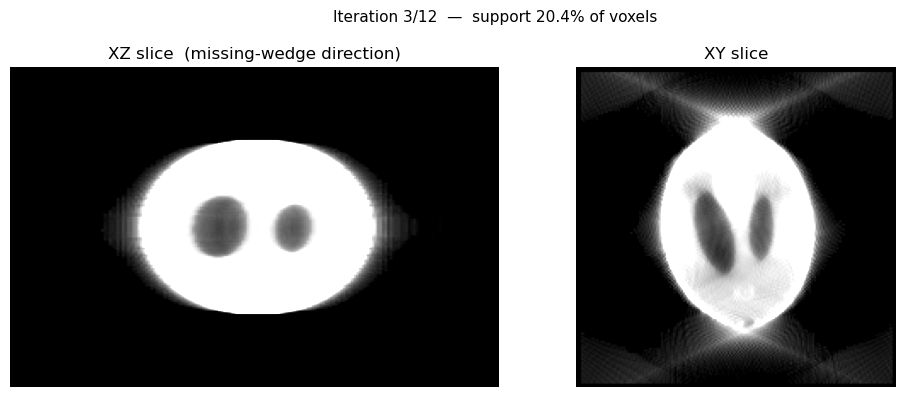

  outer 4/12 — support: 17.7% of voxels


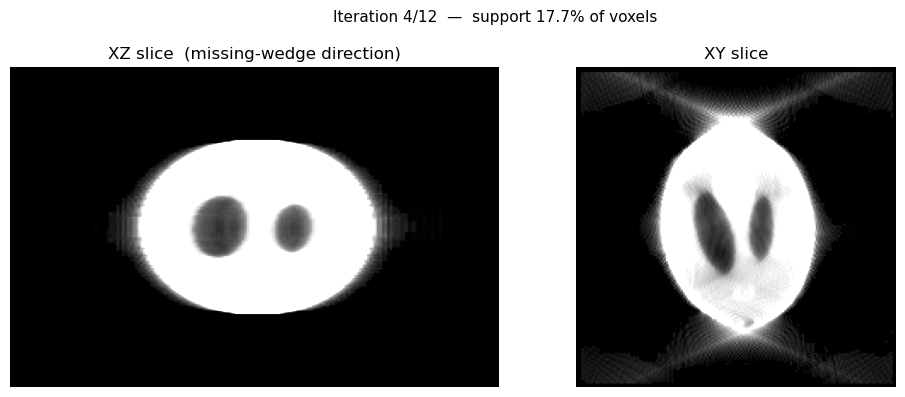

  outer 5/12 — support: 16.2% of voxels


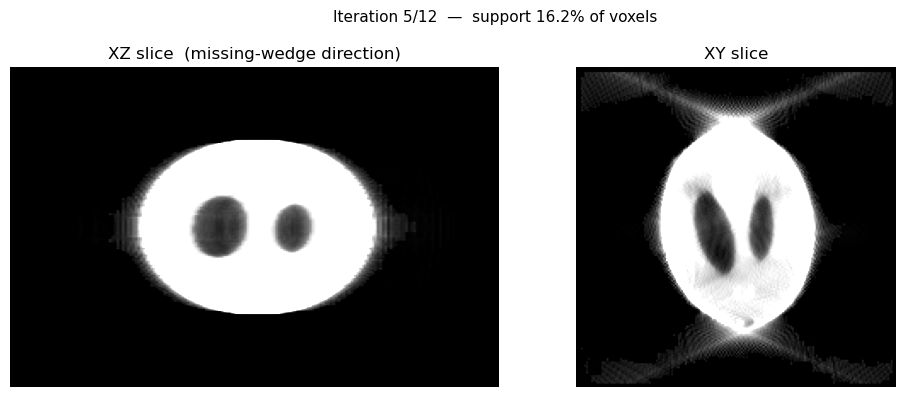

  outer 6/12 — support: 15.3% of voxels


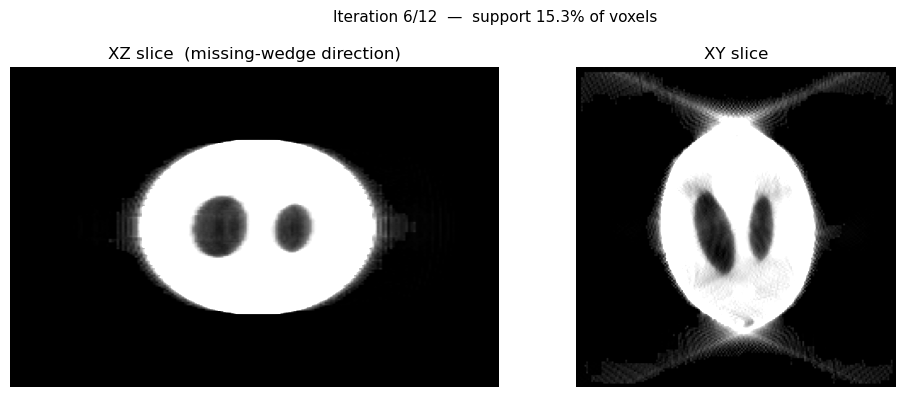

In [ ]:
# ── SIRT: one sinogram row at a time ─────────────────────────────────────
# Each call runs n_iter SIRT updates for a single 2D slice:
#   x ← x − α · Aᵀ(Ax − b),  then clip to x ≥ 0
# Passing `init` lets us resume from a previous state between outer iterations.

def sirt_slice(W, sinogram_row, N, L, n_iter, init=None):
    alpha = 0.25 / max(L, 1e-8)
    b = sinogram_row.ravel().astype(np.float32)
    x = init.ravel().astype(np.float32) if init is not None else np.zeros(N * N, np.float32)
    for _ in range(n_iter):
        residual = (W * x) - b
        x = np.maximum(x - alpha * (W.T * residual), 0.0).astype(np.float32)
    return x.reshape(N, N)


# ── POCS outer loop ───────────────────────────────────────────────────────
N_OUTER     = 12     # number of SIRT ↔ support-constraint alternations
N_INNER     = 20     # SIRT iterations per alternation
SUPPORT_THR = 0.025  # voxels above 2.5% of the volume peak are treated as 'inside the object'
CLOSE_RAD   = 6      # morphological closing radius (voxels) to fill interior holes in the mask

states = [None] * n_rows
vmin = vmax = None   # fixed from first iteration so all plots share the same colorscale

print(f'POCS: {N_OUTER} outer × {N_INNER} SIRT steps = {N_OUTER * N_INNER} total per row')

for outer in tqdm_nb(range(N_OUTER), desc='POCS outer iterations'):

    # Data-fidelity: run SIRT for every sinogram row, resuming from last state
    for row in range(n_rows):
        sino_row    = mw_projs_c[:, row, :].astype(np.float32)
        states[row] = sirt_slice(W, sino_row, N, L, N_INNER, init=states[row])

    # Compact-support constraint: threshold → morphological closing → apply mask
    volume = np.stack(states)
    thresh = SUPPORT_THR * float(volume.max())
    mask   = binary_closing(volume > thresh, structure=np.ones((CLOSE_RAD,) * 3, dtype=bool))
    for row in range(n_rows):
        states[row] = volume[row] * mask[row]

    pct = 100.0 * mask.sum() / mask.size
    print(f'  outer {outer + 1}/{N_OUTER} — support: {pct:.1f}% of voxels')

    # Fix colorscale from the first iteration so all plots are directly comparable
    if vmin is None:
        vmin, vmax = np.percentile(volume, [2, 98])

    cy = volume.shape[1] // 2
    cz = volume.shape[0] // 2
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f'Iteration {outer + 1}/{N_OUTER}  —  support {pct:.1f}% of voxels', fontsize=11)
    axes[0].imshow(volume[:, cy, :], cmap='gray', vmin=vmin, vmax=vmax, aspect='auto')
    axes[0].set_title('XZ slice  (missing-wedge direction)')
    axes[0].axis('off')
    axes[1].imshow(volume[cz, :, :], cmap='gray', vmin=vmin, vmax=vmax)
    axes[1].set_title('XY slice')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

recon_pocs = tomopy.circ_mask(np.stack(states), axis=0, ratio=0.95)
print('\nPOCS reconstruction complete.')
MoviePlotter(recon_pocs)

In [1]:
# ── Final comparison: ART baseline vs POCS with compact-support ──────────
art_baseline = tomo.recon.copy()   # ART reconstruction after alignment (from cell above)

cy = recon_pocs.shape[1] // 2    # centre Y → XZ plane (missing-wedge elongation visible here)
cz = recon_pocs.shape[0] // 2    # centre Z → XY plane

vmin, vmax = np.percentile(art_baseline, [2, 98])
panels = [('ART (base)', art_baseline), ('POCS + compact support', recon_pocs)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for col, (title, vol) in enumerate(panels):
    axes[0, col].imshow(vol[:, cy, :], cmap='gray', vmin=vmin, vmax=vmax, aspect='auto')
    axes[0, col].set_title(f'{title}\nXZ slice — elongation from missing wedge')
    axes[0, col].axis('off')
    axes[1, col].imshow(vol[cz, :, :], cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f'{title}\nXY slice')
    axes[1, col].axis('off')

plt.suptitle('ART (base) vs POCS with Compact-Support Constraint', fontsize=13)
plt.tight_layout()
plt.show()


# ── Quantitative summary ──────────────────────────────────────────────────
def elongation_factor(vol, percentile_thresh=70):
    """Z/X extent ratio in the XZ centre slice. > 1.0 means vertical elongation."""
    sl = vol[:, vol.shape[1] // 2, :]
    ys, xs = np.where(sl > np.percentile(sl, percentile_thresh))
    if len(xs) < 10:
        return np.nan
    return float(ys.max() - ys.min() + 1) / float(xs.max() - xs.min() + 1)

print('\n' + '=' * 56)
print('  RECONSTRUCTION QUALITY SUMMARY')
print('=' * 56)
print(f"  {'Method':<30} {'Gradient':>8} {'Laplacian':>10} {'Z/X ratio':>10}")
print(f"  {'-' * 54}")
for label, vol in panels:
    grad, lap, _, _ = reconstruction_sharpness_score(vol, plot=False, percentile_crop=5)
    ef = elongation_factor(vol)
    ef_str = f'{ef:.3f}' if not np.isnan(ef) else 'n/a'
    print(f"  {label:<30} {grad:>8.5f} {lap:>10.5f} {ef_str:>10}")
print(f"\n  Z/X > 1.0 = vertical missing-wedge elongation present")
print('=' * 56)

NameError: name 'tomo' is not defined